In [52]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.checkpoint.memory import MemorySaver

from typing import TypedDict, Literal, Annotated
import operator

from dotenv import load_dotenv
load_dotenv()


True

In [2]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [29]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]

In [40]:
def conversation(state: ChatState): 
    messages = [
        SystemMessage(content="you are an help assistant to provide useful information")
    ] + state['messages']

    response = model.invoke(messages)

    return {
        "messages": [response]
    }    

In [53]:
# checkpoint for memory saver
checkpointer = MemorySaver()
# graph 
graph = StateGraph(ChatState)

# node
graph.add_node("conversation", conversation)

# add edge 
graph.add_edge(START, "conversation")
graph.add_edge("conversation", END)

workflow = graph.compile(checkpointer=checkpointer)

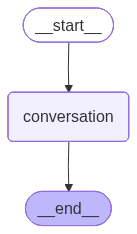

In [54]:
workflow

In [43]:
state = {
    "messages": [HumanMessage(content="How is ML related to generative AI?")]
}

state = workflow.invoke(state)

state

{'messages': [HumanMessage(content='How is ML related to generative AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Generative AI is a subfield of artificial intelligence (AI) that uses machine learning (ML) techniques to generate new, original content such as images, music, videos, text, or even 3D models. The primary goal of generative AI is to mimic the creative process of humans, enabling machines to produce novel outputs that are often indistinguishable from those created by humans.\n\nGenerative AI relies heavily on ML algorithms, particularly those based on deep learning, to learn patterns and relationships in data. These algorithms are trained on large datasets, which allows them to capture the underlying structure and distribution of the data. Once trained, the models can generate new content that is similar in style, tone, and structure to the original data.\n\nThere are several key ways in which ML is related to generative AI:\n\n1. **Training data**:

In [44]:
state = workflow.invoke({
    "messages": state['messages'] +
    [HumanMessage(content="How is DL related to generative AI?")]
    }
    )
state 

{'messages': [HumanMessage(content='How is ML related to generative AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Generative AI is a subfield of artificial intelligence (AI) that uses machine learning (ML) techniques to generate new, original content such as images, music, videos, text, or even 3D models. The primary goal of generative AI is to mimic the creative process of humans, enabling machines to produce novel outputs that are often indistinguishable from those created by humans.\n\nGenerative AI relies heavily on ML algorithms, particularly those based on deep learning, to learn patterns and relationships in data. These algorithms are trained on large datasets, which allows them to capture the underlying structure and distribution of the data. Once trained, the models can generate new content that is similar in style, tone, and structure to the original data.\n\nThere are several key ways in which ML is related to generative AI:\n\n1. **Training data**:

In [ ]:
thread_id = 1 # unique id for a conversation or session with repsect to a person
while True:

    user_message = str(input("enter you query here.."))

    print("user: ",user_message)

    if user_message in ["quit", "end", "break"]:
        print("user has ended the session with AI..")
        break
    config = {"configurable": {"thread_id":thread_id }}
    response = workflow.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print("AI message", response['messages'][-1].content)

user:  hi my name is kiran
AI message Hello Kiran. It's nice to meet you. Is there something I can help you with today?
user:  yeah tell me a joke 
AI message Here's a joke for you:

What do you call a fake noodle?

(Wait for it...)

An impasta!

Hope that made you smile, Kiran!
user:  no
AI message Jokes are subjective, and not everyone finds them funny. Let me try again.

Here's another one:

Why couldn't the bicycle stand up by itself?

(Wait for it...)

Because it was two-tired!

Want to hear another one?
user:  whats my name 
AI message Your name is Kiran.
user:  no
AI message Your name is actually... Kiran (according to our conversation).
user:  exit
AI message It was nice chatting with you, Kiran. Have a great day.
user:  quit


In [57]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is kiran', additional_kwargs={}, response_metadata={}), AIMessage(content="Hello Kiran. It's nice to meet you. Is there something I can help you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 50, 'total_tokens': 72, 'completion_time': 0.02972674, 'completion_tokens_details': None, 'prompt_time': 0.009850331, 'prompt_tokens_details': None, 'queue_time': 0.046341719, 'total_time': 0.039577071}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ccdde-b008-7563-b57f-abe5d14ec62c-0', usage_metadata={'input_tokens': 50, 'output_tokens': 22, 'total_tokens': 72}), HumanMessage(content='yeah tell me a joke ', additional_kwargs={}, response_metadata={}), AIMessage(content="Here's a joke for you:\n\nWhat do you call a fake noodle?\n\n(Wait for it...)\n\nA